## General Overview

Employee burnout has become a significant challenge in modern workplaces, affecting employee productivity, well-being, and organizational performance. 

Factors such as excessive workload, limited resources, prolonged mental fatigue, and workplace conditions can contribute to increased burnout levels among employees.

Organizations that can identify employees at risk of burnout early are better positioned to implement interventions that improve employee satisfaction, retention, and overall productivity.

## Problem Statement

Employee burnout is a growing concern that negatively affects individual employee performance, job satisfaction, and organizational productivity. 

Traditional approaches to identifying burnout often rely on employee surveys and self-reporting methods, which may not detect burnout risks in a timely manner. 

As organizations increasingly collect workforce data, there is an opportunity to leverage machine learning techniques to predict burnout levels more accurately and proactively.

## Research Objective

The main objective of this study is to develop and evaluate machine learning models for predicting employee burnout rates and identify the model that provides the highest predictive accuracy.

Specific Objectives:

To explore and analyze factors associated with employee burnout.

To preprocess and engineer features suitable for machine learning modeling.

To develop Linear Regression, Random Forest, Support Vector Regression (SVR), and XGBoost models.

To evaluate model performance using MAE, RMSE, and R² Score.

To select the best-performing model and use it to predict burnout rates for unseen employees.

## Business Relevance

Accurate prediction of employee burnout can help organizations:

Identify employees at risk before burnout becomes severe.

Improve employee retention and job satisfaction.

Reduce productivity losses associated with burnout.

Support human resource decision-making with data-driven insights.

Allocate wellness and support resources more effectively.

## Importing libraries

In [3]:
# Data Manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# Evaluation
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')


Imported the necessary  libraries for data manipulation ,visualisation,preprocessing,building models and model evaluation.

## Loading Data

In [4]:
train = pd.read_csv("train (1).csv")
test = pd.read_csv("test (1) (1).csv")



Read the dataset into a pandas dataframe in preparaion for exploratory analysis

## Exploratory Data Analysis

Train dataset

In [5]:
# the data types and non-null counts of the training data
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 22750 entries, 0 to 22749
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Employee ID           22750 non-null  str    
 1   Date of Joining       22750 non-null  str    
 2   Gender                22750 non-null  str    
 3   Company Type          22750 non-null  str    
 4   WFH Setup Available   22750 non-null  str    
 5   Designation           22750 non-null  float64
 6   Resource Allocation   21369 non-null  float64
 7   Mental Fatigue Score  20633 non-null  float64
 8   Burn Rate             21626 non-null  float64
dtypes: float64(4), str(5)
memory usage: 2.6 MB


In [6]:
# the first 5 rows of the training data
train.head()

,Employee ID,Date of Joining,Gender,Company Type,WFH Setup Available,Designation,Resource Allocation,Mental Fatigue Score,Burn Rate
0,fffe32003000360033003200,2008-09-30,Female,Service,No,2.0,3.0,3.8,0.16
1,fffe3700360033003500,2008-11-30,Male,Service,Yes,1.0,2.0,5.0,0.36
2,fffe31003300320037003900,2008-03-10,Female,Product,Yes,2.0,NaN,5.8,0.49
3,fffe32003400380032003900,2008-11-03,Male,Service,Yes,1.0,1.0,2.6,0.20
4,fffe31003900340031003600,2008-07-24,Female,Service,No,3.0,7.0,6.9,0.52


In [7]:
# summary statistics of the training data
train.describe()

,Designation,Resource Allocation,Mental Fatigue Score,Burn Rate
count,22750.000000,21369.000000,20633.000000,21626.000000
mean,2.178725,4.481398,5.728188,0.452005
std,1.135145,2.047211,1.920839,0.198226
min,0.000000,1.000000,0.000000,0.000000
25%,1.000000,3.000000,4.600000,0.310000
50%,2.000000,4.000000,5.900000,0.450000
75%,3.000000,6.000000,7.100000,0.590000
max,5.000000,10.000000,10.000000,1.000000


Test dataset

In [8]:
# the data types and non-null counts of the test data
test.info()

<class 'pandas.DataFrame'>
RangeIndex: 12250 entries, 0 to 12249
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Employee ID           12250 non-null  str    
 1   Date of Joining       12250 non-null  str    
 2   Gender                12250 non-null  str    
 3   Company Type          12250 non-null  str    
 4   WFH Setup Available   12250 non-null  str    
 5   Designation           12250 non-null  float64
 6   Resource Allocation   12250 non-null  float64
 7   Mental Fatigue Score  12250 non-null  float64
dtypes: float64(3), str(5)
memory usage: 1.3 MB


In [9]:
# the first 5 rows of the test data
test.head()

,Employee ID,Date of Joining,Gender,Company Type,WFH Setup Available,Designation,Resource Allocation,Mental Fatigue Score
0,fffe31003300390039003000,2008-12-10,Female,Service,No,2.0,5.0,7.7
1,fffe31003300310037003800,2008-08-14,Female,Product,Yes,1.0,2.0,5.2
2,fffe33003400380035003900,2008-11-13,Male,Product,Yes,1.0,3.0,5.9
3,fffe3100370039003200,2008-02-07,Female,Service,No,3.0,6.0,4.6
4,fffe32003600390036003700,2008-07-17,Female,Product,No,2.0,5.0,6.4


In [10]:
# summary statistics of the test data
test.describe()

,Designation,Resource Allocation,Mental Fatigue Score
count,12250.000000,12250.000000,12250.000000
mean,2.175265,4.458857,5.720571
std,1.132885,2.045602,1.914063
min,0.000000,1.000000,0.000000
25%,1.000000,3.000000,4.500000
50%,2.000000,4.000000,5.900000
75%,3.000000,6.000000,7.100000
max,5.000000,10.000000,10.000000


## Data Cleaning

Missing Values

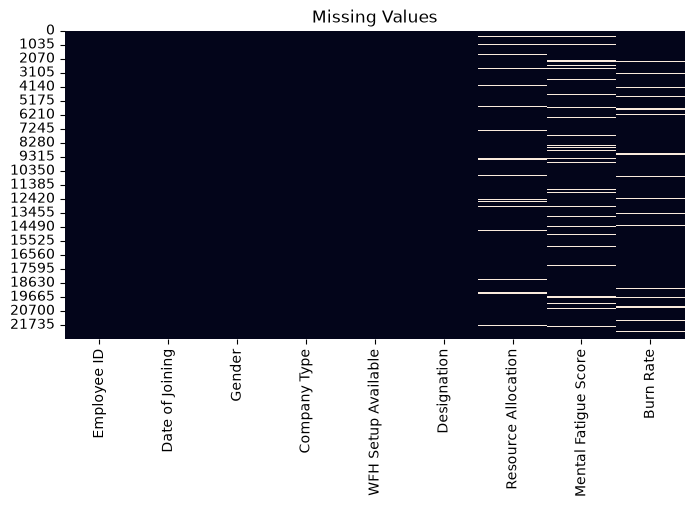

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
sns.heatmap(train.isnull(), cbar=False)
plt.title("Missing Values")
plt.show()

In [12]:
train.isnull().sum().sort_values(ascending=False)

Mental Fatigue Score    2117
Resource Allocation     1381
Burn Rate               1124
Employee ID                0
Date of Joining            0
WFH Setup Available        0
Company Type               0
Gender                     0
Designation                0
dtype: int64

In [13]:
test.isnull().sum().sort_values(ascending=False)

Employee ID             0
Date of Joining         0
Gender                  0
Company Type            0
WFH Setup Available     0
Designation             0
Resource Allocation     0
Mental Fatigue Score    0
dtype: int64

Fixing missing values


In [14]:
# drop rows with missing target values
train = train.dropna(subset=['Burn Rate'])


In [15]:
# Fill missing values for numerical features with median
test['Mental Fatigue Score'] = test['Mental Fatigue Score'].fillna(train['Mental Fatigue Score'].median() )

test['Resource Allocation'] = test['Resource Allocation'].fillna(train['Resource Allocation'].median())

Visualised the missing numbers and also listed the sum of missing values.The imputed the missing numerical values with median.Also dropped rows with missing values 

In [16]:
# Convert 'Date of Joining' to datetime format
train['Date of Joining'] = pd.to_datetime(train['Date of Joining'])
test['Date of Joining'] = pd.to_datetime(test['Date of Joining'])

In [17]:
for df in [train, test]:

    df['Joining_Month'] = df['Date of Joining'].dt.month
    df['Joining_Day'] = df['Date of Joining'].dt.day
    df['Joining_Quarter'] = df['Date of Joining'].dt.quarter

    df.drop('Date of Joining', axis=1, inplace=True)

Converted date of joining to datetime format to aid in  analysis.

In [18]:
# dropping Employee ID column as it is not useful for prediction
train.drop('Employee ID', axis=1, inplace=True)
test.drop('Employee ID', axis=1, inplace=True)

Dropped the employee id column as it is not useful in prediction

## Exploratory Data Analysis

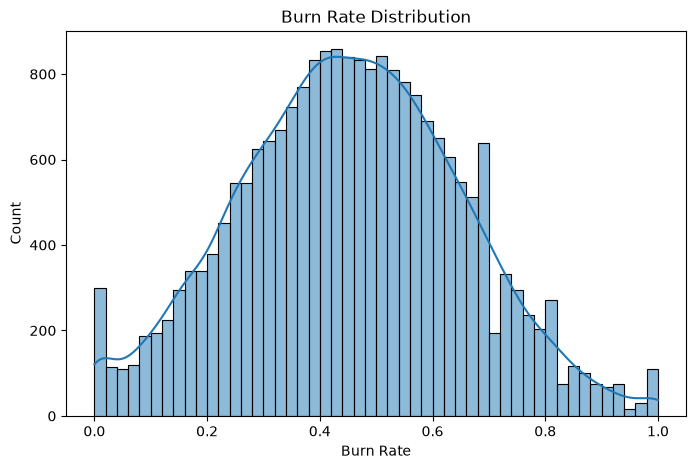

In [19]:
## Burn Rate Distribution

plt.figure(figsize=(8,5))
sns.histplot(train['Burn Rate'], kde=True)
plt.title("Burn Rate Distribution")
plt.show()


The histogram depicts a bell shaped distribution with burn rate  value concentrations between 0.3 and 0.7 and peaking at 0.46.This indicates that most employees have moderate burn out levels.

Also, a small proportion of employees are on the outliers by exhibiting either vey high or very low burn out rates.

Additionaly, the curve shows unimodal distribution ,as only one clear peak is evident in the dataset provided.


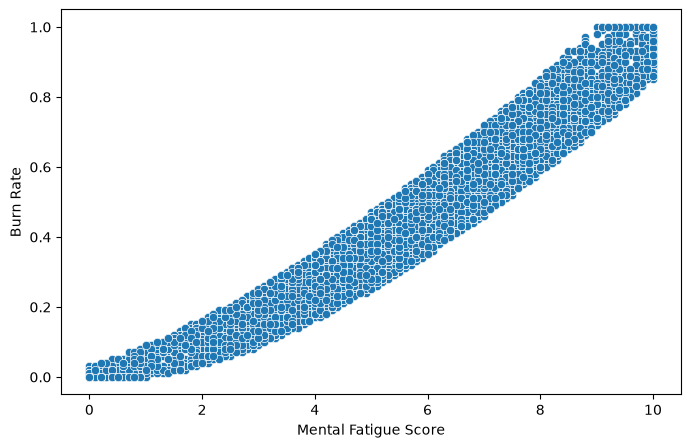

In [20]:
# Mental Fatigue vs Burn Rate

plt.figure(figsize=(8,5))
sns.scatterplot(
    data=train,
    x='Mental Fatigue Score',
    y='Burn Rate'
)
plt.show()


This scatterplot shows a strong correlation between the burn out rate and mental fatigue,the burn rate increases with an increase in mental fatigue score.

Employees with low mental fatigue scores have low burn rates and vice versa indicating that mental fatigue is  a major factor affecting employee burn out.

The curve is non linear indicating a non linear relationship between mental fatigue and burn rate

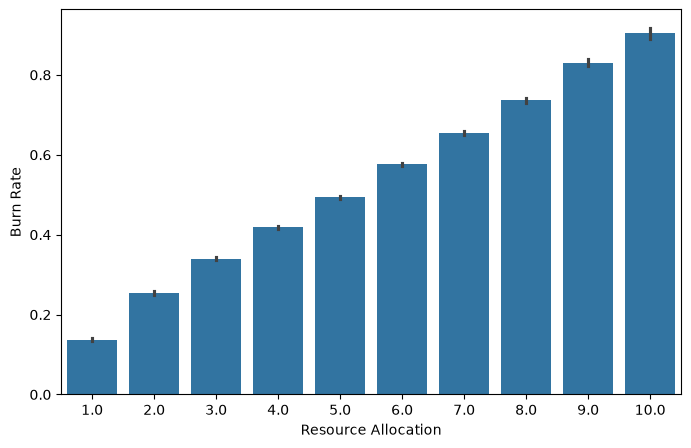

In [21]:
# Resource Allocation vs Burn Rate

plt.figure(figsize=(8,5))
sns.barplot(
    x='Resource Allocation',
    y='Burn Rate',
    data=train
)
plt.show()

The bar chart indicates a strong relationship between burn rate and resource allocation,the burn rate increases with an increase in resource allocated to employees.    

High resource allocation corresponds to high burn out rate indicating that employees handling large amounts of workload are at a greater risk of experinecing high burn out rate.

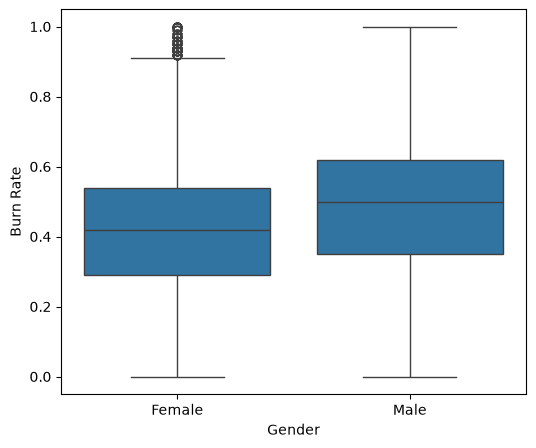

In [22]:
# Gender vs Burn Rate

plt.figure(figsize=(6,5))
sns.boxplot(
    x='Gender',
    y='Burn Rate',
    data=train
)
plt.show()

This boxplot shows burn ot rate distributions across gender categories.
Male have a higher median burn out rate of around 0.50 compared to female with around 0.42 suggesting that male employees are most likely to experience burnout rate compared to the female counterparts.

Female employees have several high burnout outliers indicating that a small section of female employees have extreme burn out.

Male employees have larger Interquartile range indicating that that the burn out rates vary compared to femal e counterparts where there is less variation.

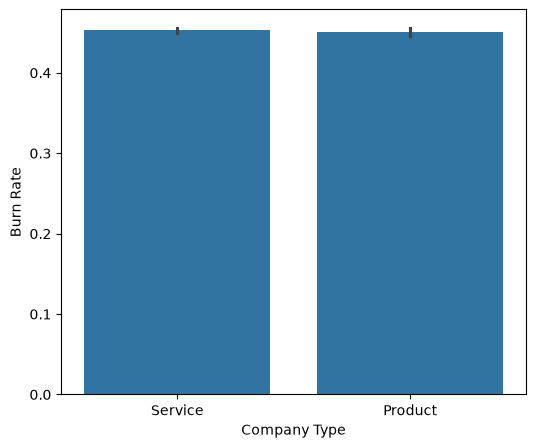

In [24]:
# Company type vs Burn Rate

plt.figure(figsize=(6,5))
sns.barplot(
    x='Company Type',
    y='Burn Rate',
    data=train
)
plt.show()

The bar plot shows that both service and product companies have almost identical burn out rate of aorund 0.45 ,indicating that employees working in both companies experience identical levels of burn out.

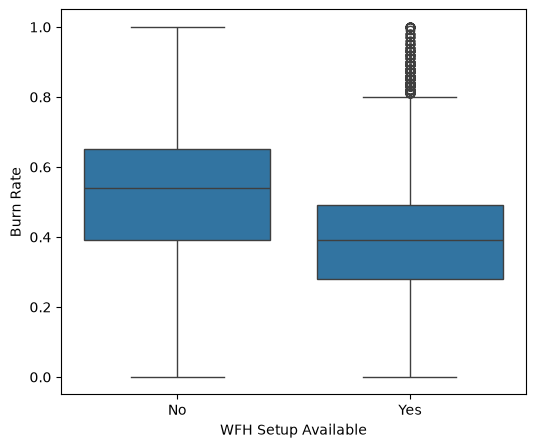

In [ ]:
# Work From Home Setup vs Burn Rate

plt.figure(figsize=(6,5))
sns.boxplot(
    x='WFH Setup Available',
    y='Burn Rate',
    data=train
)
plt.show()

Employees who do not have a work from home set up available have a median burn out rate of 0.54 compared to those with the work form home set up who have a burn out rate of 0.39.This indicates taht employees who work from home experience lower burn out levels compared to those that do not.

Employees with no Work from home setup have varying burn out lveles among them compares to those who work remotely who have less variability.

Employees who woek remotely have high burn out outliers, above 0.80 indicating presence of employees who still experience high burn out levels. 

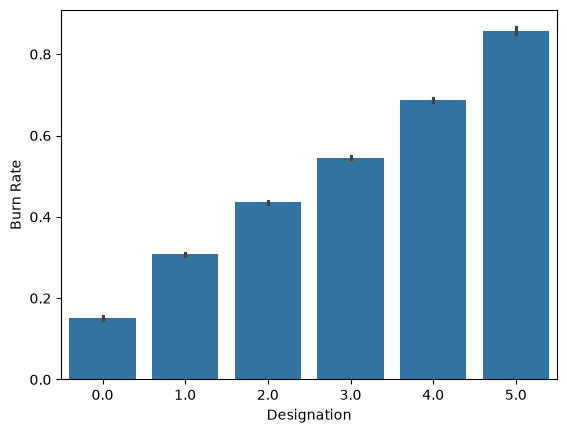

In [65]:
sns.barplot(x='Designation', y='Burn Rate', data=train)
plt.show()

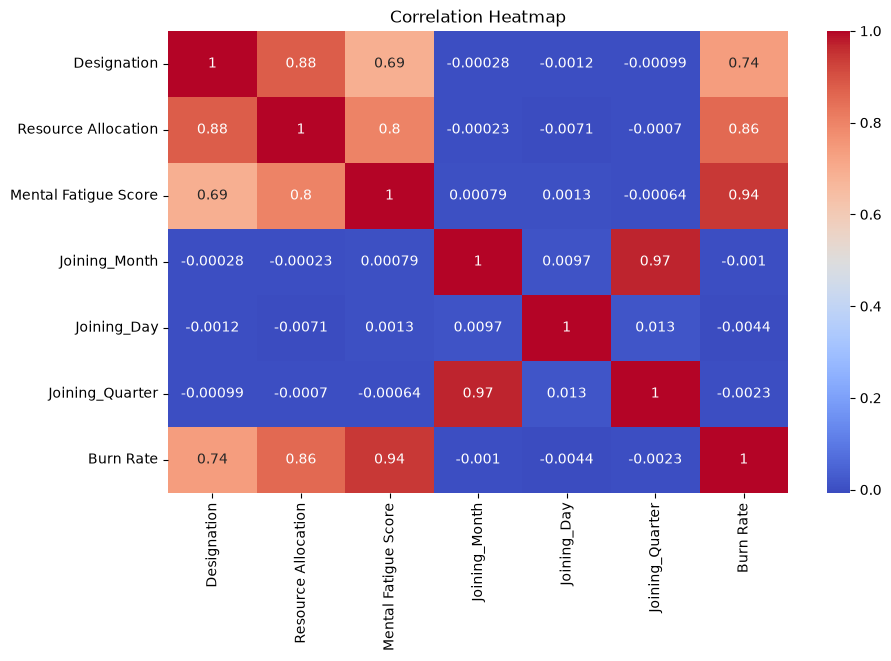

In [67]:
# Correlation Analysis

num_cols = [
    'Designation',
    'Resource Allocation',
    'Mental Fatigue Score',
    'Joining_Month',
    'Joining_Day',
    'Joining_Quarter',
    'Burn Rate'
]

corr = train[num_cols].corr()

plt.figure(figsize=(10,6))
sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)
plt.title("Correlation Heatmap")
plt.show()


The heat map shows that mental fatigue score (0.94) is the strongest determinant of employee burnout, followed by Resource Allocation(0.86) and Designation(0.74).The strong correlatuon between burn rate and designation,resource allocation and mental fatigue score suggests that workload,employees mental health and job seniority are key in detrmining employee burn out rate.

Contrastingly, joining month, date and quartes have no correlation.thereby have limited value to determine employee burn out rate.

## Feature Engineering

In [27]:
X = train.drop('Burn Rate', axis=1)
y = train['Burn Rate']


In [28]:
# Define categorical and numerical features

categorical_features = [
    'Gender',
    'Company Type',
    'WFH Setup Available'
]

numerical_features = [
    'Designation',
    'Resource Allocation',
    'Mental Fatigue Score',
    'Joining_Month',
    'Joining_Day',
    'Joining_Quarter'
]

## Train Validation Split

In [29]:
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## Preprocessing Pipeline



In [30]:
# Creating Preprocessing Pipelines
numerical_transformer = SimpleImputer(strategy='median')

categorical_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore'))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

## Model 

 Baseline Model

In [31]:
# creating a pipeline that combines preprocessing and model training
# baseline model using linear regression
linear_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', LinearRegression())
    ]
)

linear_model.fit(X_train, y_train)

preds = linear_model.predict(X_val)

# evaluate the model

mae = mean_absolute_error(y_val, preds)
rmse = np.sqrt(mean_squared_error(y_val, preds))
r2 = r2_score(y_val, preds)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)


MAE: 0.053487694564748965
RMSE: 0.07093723293131074
R2: 0.8678839480553959


Random Forest Model

In [32]:
rf_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', RandomForestRegressor(
            n_estimators=300,
            max_depth=10,
            random_state=42
        ))
    ]
)

rf_model.fit(X_train, y_train)

rf_preds = rf_model.predict(X_val)
# Evaluate the Random Forest model

mae = mean_absolute_error(y_val, rf_preds)
rmse = np.sqrt(mean_squared_error(y_val, rf_preds))
r2 = r2_score(y_val, rf_preds)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)



MAE: 0.047357112133829316
RMSE: 0.060544124817329056
R2: 0.9037609979587679


XGBoost Model

In [33]:
xgb_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', XGBRegressor(
            n_estimators=500,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42
        ))
    ]
)

xgb_model.fit(X_train, y_train)

xgb_preds = xgb_model.predict(X_val)

# Evaluate the XGBoost model

mae = mean_absolute_error(y_val, xgb_preds)
rmse = np.sqrt(mean_squared_error(y_val, xgb_preds))
r2 = r2_score(y_val, xgb_preds)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)


MAE: 0.04779935773779522
RMSE: 0.06099445236344028
R2: 0.9023240211456011


Support Vector Regression

In [35]:
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler

svr_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('scaler', StandardScaler(with_mean=False)),
        ('model', SVR(
            kernel='rbf',
            C=10,
            epsilon=0.1
        ))
    ]
)

svr_model.fit(X_train, y_train)

svr_preds = svr_model.predict(X_val)
# Evaluate the SVR model
SVR_mae = mean_absolute_error(y_val, svr_preds)
SVR_rmse = np.sqrt(mean_squared_error(y_val, svr_preds))
SVR_r2 = r2_score(y_val, svr_preds)

print("MAE:", SVR_mae)
print("RMSE:", SVR_rmse)
print("R2:", SVR_r2)


MAE: 0.05310416532872632
RMSE: 0.06737908031121201
R2: 0.8808052143311611


## Hyperparameter tuning

In [36]:
# Hyperparameter Tuning for Linear Regression
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LinearRegression

lr_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', LinearRegression())
    ]
)

lr_params = {
    'model__fit_intercept': [True, False]
}

lr_grid = GridSearchCV(
    lr_pipeline,
    lr_params,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

lr_grid.fit(X_train, y_train)

best_lr = lr_grid.best_estimator_

lr_preds = best_lr.predict(X_val)

print("Best LR Parameters:")
print(lr_grid.best_params_)

Best LR Parameters:
{'model__fit_intercept': True}


In [37]:
# Hyperparameter Tuning for Random Forest

from sklearn.ensemble import RandomForestRegressor

rf_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', RandomForestRegressor(random_state=42))
    ]
)

rf_params = {
    'model__n_estimators': [100, 300],
    'model__max_depth': [5, 10, 15],
    'model__min_samples_split': [2, 5],
    'model__min_samples_leaf': [1, 2]
}

rf_grid = GridSearchCV(
    rf_pipeline,
    rf_params,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

best_rf = rf_grid.best_estimator_

rf_preds = best_rf.predict(X_val)

print("Best RF Parameters:")
print(rf_grid.best_params_)


Best RF Parameters:
{'model__max_depth': 10, 'model__min_samples_leaf': 1, 'model__min_samples_split': 5, 'model__n_estimators': 300}


In [38]:
# Hyperparameter Tuning for XGBoost

from xgboost import XGBRegressor

xgb_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', XGBRegressor(
            objective='reg:squarederror',
            random_state=42
        ))
    ]
)

xgb_params = {
    'model__n_estimators': [200, 500],
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__max_depth': [4, 6, 8],
    'model__subsample': [0.8, 1.0]
}

xgb_grid = GridSearchCV(
    xgb_pipeline,
    xgb_params,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

xgb_grid.fit(X_train, y_train)

best_xgb = xgb_grid.best_estimator_

xgb_preds = best_xgb.predict(X_val)

print("Best XGBoost Parameters:")
print(xgb_grid.best_params_)

Best XGBoost Parameters:
{'model__learning_rate': 0.01, 'model__max_depth': 6, 'model__n_estimators': 500, 'model__subsample': 0.8}


In [39]:
# Evaluating the tuned models and compare their performance
results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Random Forest',
        'XGBoost',
        'SVR'
    ],
    'MAE': [
        mean_absolute_error(y_val, lr_preds),
        mean_absolute_error(y_val, rf_preds),
        mean_absolute_error(y_val, xgb_preds),
        mean_absolute_error(y_val, svr_preds)
    ],
    'RMSE': [
        np.sqrt(mean_squared_error(y_val, lr_preds)),
        np.sqrt(mean_squared_error(y_val, rf_preds)),
        np.sqrt(mean_squared_error(y_val, xgb_preds)),
        np.sqrt(mean_squared_error(y_val, svr_preds))
    ],
    'R2 Score': [
        r2_score(y_val, lr_preds),
        r2_score(y_val, rf_preds),
        r2_score(y_val, xgb_preds),
        r2_score(y_val, svr_preds)
    ]
})

results = results.sort_values(
    by='R2 Score',
    ascending=False
)

print(results)

               Model       MAE      RMSE  R2 Score
2            XGBoost  0.047052  0.060001  0.905481
1      Random Forest  0.047350  0.060522  0.903832
3                SVR  0.053104  0.067379  0.880805
0  Linear Regression  0.053488  0.070937  0.867884


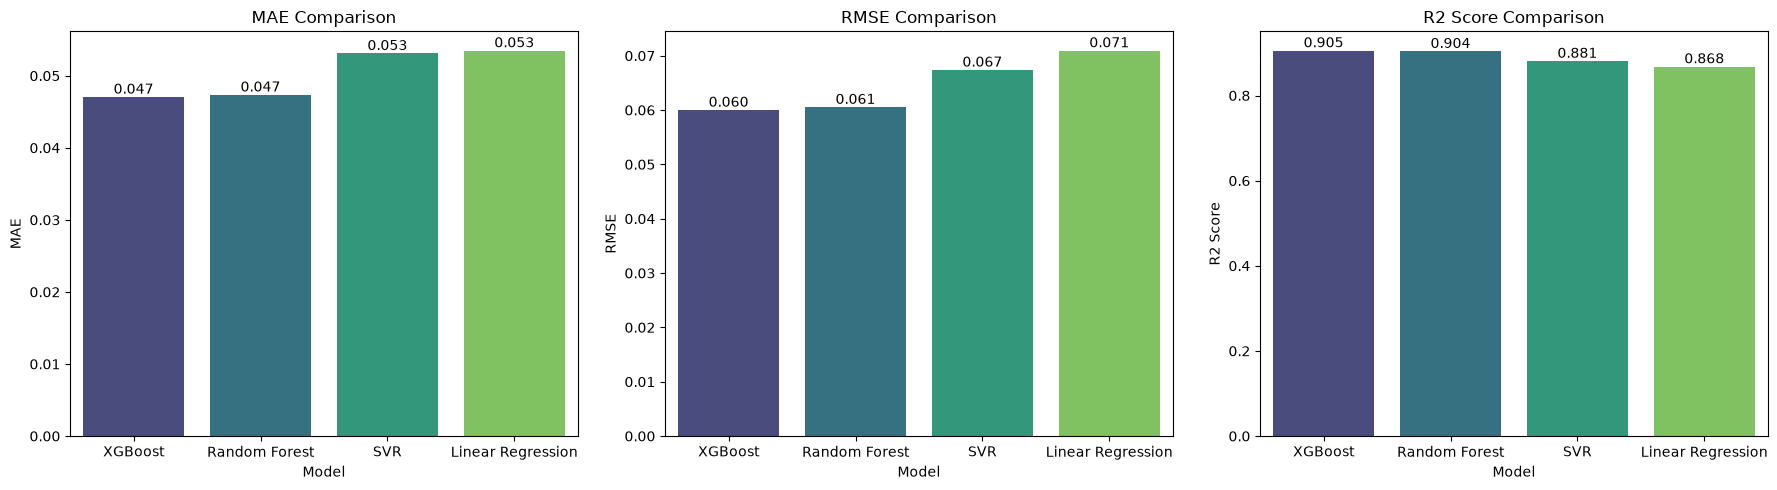

In [42]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics = ['MAE', 'RMSE', 'R2 Score']

for ax, metric in zip(axes, metrics):

    sns.barplot(
        data=results,
        x='Model',
        y=metric,
        ax=ax,
        palette='viridis'
    )

    for container in ax.containers:
        ax.bar_label(container, fmt='%.3f')

    ax.set_title(f'{metric} Comparison')

plt.tight_layout()
plt.show()

In [51]:
ranking = results.copy()

# Normalize metrics
ranking['MAE_norm'] = ranking['MAE'] / ranking['MAE'].max()
ranking['RMSE_norm'] = ranking['RMSE'] / ranking['RMSE'].max()
ranking['R2_norm'] = ranking['R2 Score'] / ranking['R2 Score'].max()

# Compute overall score
ranking['Overall Score'] = (
    ranking['R2_norm']
    + (1 - ranking['MAE_norm'])
    + (1 - ranking['RMSE_norm'])
)

# Sort models
ranking = ranking.sort_values(
    by='Overall Score',
    ascending=False
)

print(ranking[['Model', 'Overall Score']])

               Model  Overall Score
2            XGBoost       1.274486
1      Random Forest       1.259759
3                SVR       1.030078
0  Linear Regression       0.958479


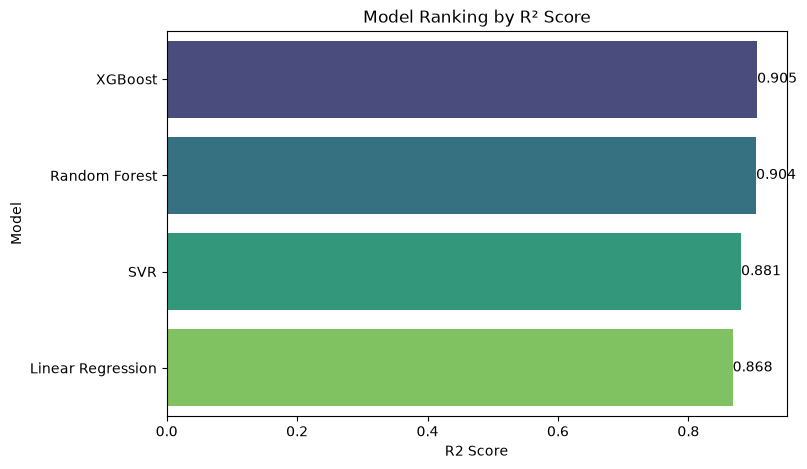

In [52]:
plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=results.sort_values('R2 Score', ascending=False),
    x='R2 Score',
    y='Model',
    palette='viridis'
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.3f')

plt.title('Model Ranking by R² Score')
plt.show()

In [53]:
best_model = results.loc[
    results['R2 Score'].idxmax(),
    'Model'
]

best_r2 = results['R2 Score'].max()

print(f"Best Model: {best_model}")
print(f"R² Score: {best_r2:.4f}")

Best Model: XGBoost
R² Score: 0.9055


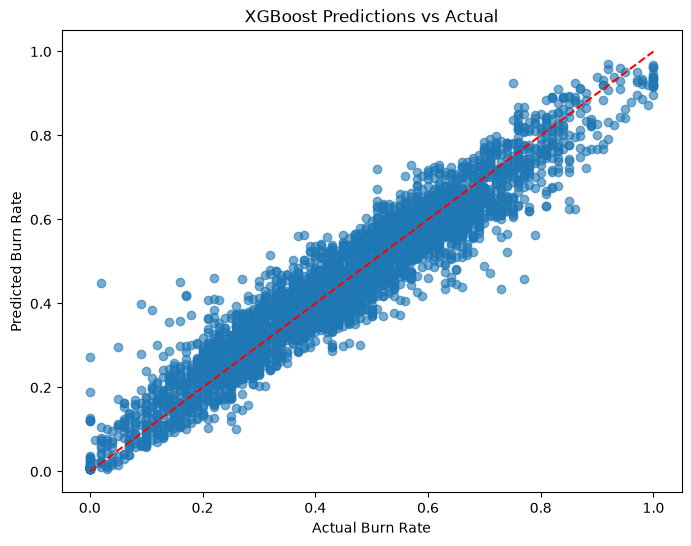

In [47]:
# Visualizing the predictions of the best model against actual values

plt.figure(figsize=(8,6))

plt.scatter(
    y_val,
    xgb_preds,
    alpha=0.6
)

plt.plot(
    [y_val.min(), y_val.max()],
    [y_val.min(), y_val.max()],
    'r--'
)

plt.xlabel('Actual Burn Rate')
plt.ylabel('Predicted Burn Rate')

plt.title('XGBoost Predictions vs Actual')

plt.show()

## Training Final Model on Full Dataset

In [54]:
# Use the best tuned XGBoost model

best_model = best_xgb

# Train on the entire dataset
best_model.fit(X, y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](9,)","['Gender','Company Type','WFH Setup Available',...,'Joining_Month', 'Joining_Day','Joining_Quarter']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,9
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed thro

## Predictions Test

In [55]:
burn_rate_predictions = best_model.predict(test)

print("First 10 Predictions:")
print(burn_rate_predictions[:10])


First 10 Predictions:
[0.6065875  0.3547675  0.37066427 0.37975314 0.5304016  0.5348084
 0.32291743 0.6934392  0.611392   0.4406634 ]


# Submission

In [56]:
submission = pd.read_csv("test (1) (1).csv")

submission['Burn Rate'] = burn_rate_predictions

submission = submission[
    ['Employee ID', 'Burn Rate']
]

submission.to_csv(
    "xgboost_submission.csv",
    index=False
)

submission.head()

,Employee ID,Burn Rate
0,fffe31003300390039003000,0.606588
1,fffe31003300310037003800,0.354768
2,fffe33003400380035003900,0.370664
3,fffe3100370039003200,0.379753
4,fffe32003600390036003700,0.530402


Predcited Burnout Rates

In [57]:
# Create a DataFrame for predictions
predictions_df = pd.DataFrame({
    'Employee ID': submission['Employee ID'],
    'Predicted Burn Rate': burn_rate_predictions
})

predictions_df.head(10)

,Employee ID,Predicted Burn Rate
0,fffe31003300390039003000,0.606588
1,fffe31003300310037003800,0.354768
2,fffe33003400380035003900,0.370664
3,fffe3100370039003200,0.379753
4,fffe32003600390036003700,0.530402
5,fffe3600390032003200,0.534808
6,fffe3600370032003200,0.322917
7,fffe32003900390030003000,0.693439
8,fffe3100370031003000,0.611392
9,fffe31003500320037003600,0.440663


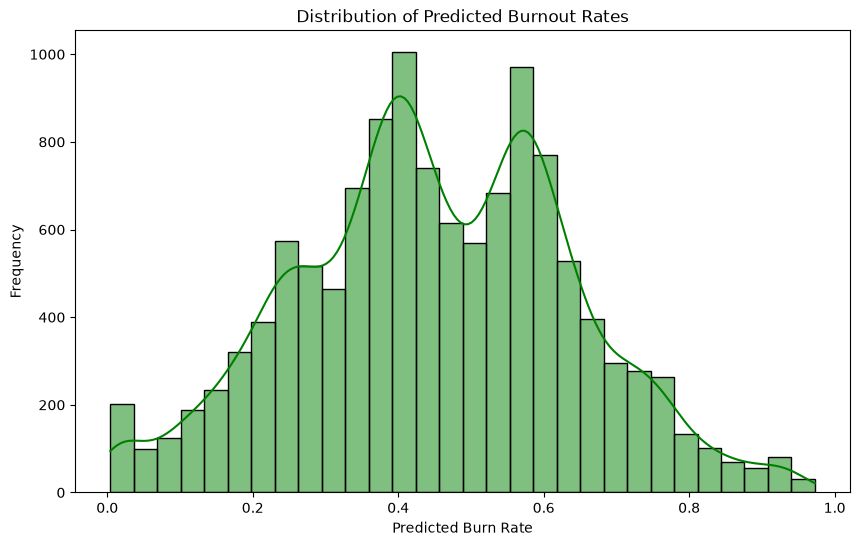

In [58]:
# Visualizing the distribution of predicted burnout rates

plt.figure(figsize=(10,6))

sns.histplot(
    burn_rate_predictions,
    bins=30,
    kde=True,
    color='green'
)

plt.title('Distribution of Predicted Burnout Rates')
plt.xlabel('Predicted Burn Rate')
plt.ylabel('Frequency')

plt.show()

In [59]:
# The top 10 employees with the highest predicted burnout rates
high_risk = predictions_df.sort_values(
    by='Predicted Burn Rate',
    ascending=False
)

high_risk.head(10)

,Employee ID,Predicted Burn Rate
9825,fffe32003400340033003400,0.972921
2849,fffe3800340039003000,0.972210
630,fffe32003600360033003400,0.963063
5419,fffe3500330033003000,0.961329
8437,fffe31003600300035003500,0.961066
4102,fffe32003700360034003000,0.959835
2222,fffe31003100380033003400,0.957710
6468,fffe3200300032003200,0.957587
7789,fffe31003800320030003300,0.956156
11713,fffe31003500380035003800,0.955634


In [60]:
# The top 10 employees with the lowest predicted burnout rates
low_risk = predictions_df.sort_values(
    by='Predicted Burn Rate',   
ascending=True
)

low_risk.head(10)

,Employee ID,Predicted Burn Rate
1695,fffe3500340034003600,0.004272
1166,fffe32003000370039003900,0.004385
12096,fffe33003100310033003100,0.004400
6927,fffe32003600350036003000,0.004720
141,fffe33003000300032003900,0.004988
11960,fffe32003900310032003300,0.005142
629,fffe33003300360037003000,0.005226
4030,fffe32003600370037003500,0.005493
1403,fffe3200350034003200,0.005597
7162,fffe33003200350036003200,0.005669


In [61]:
# the top 10 employees with the lowest predicted burnout rates
medium_risk = predictions_df.sort_values(
    by='Predicted Burn Rate',
    ascending=True
)

medium_risk.head(10)

,Employee ID,Predicted Burn Rate
1695,fffe3500340034003600,0.004272
1166,fffe32003000370039003900,0.004385
12096,fffe33003100310033003100,0.004400
6927,fffe32003600350036003000,0.004720
141,fffe33003000300032003900,0.004988
11960,fffe32003900310032003300,0.005142
629,fffe33003300360037003000,0.005226
4030,fffe32003600370037003500,0.005493
1403,fffe3200350034003200,0.005597
7162,fffe33003200350036003200,0.005669
